In [527]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from numpy import unique
from numpy import where
from matplotlib import pyplot

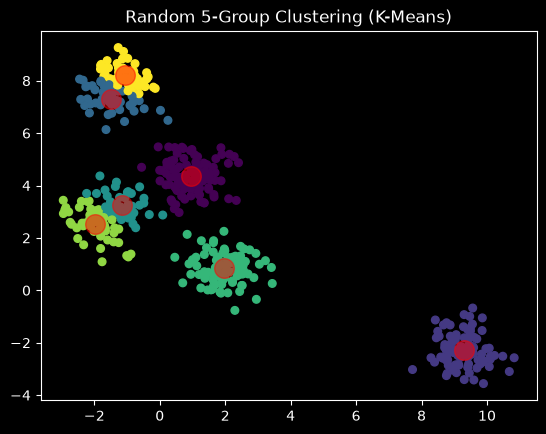

In [528]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=500, centers=5, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=7, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.title("Random 5-Group Clustering (K-Means)")
plt.show()

In [529]:
kmeans_model = KMeans(n_clusters=3)
km = KMeans(n_clusters=3,init="k-means++", n_init=10, max_iter=300)
training_data = X
km.fit(training_data)
error = km.inertia_
kmeans_model.fit(training_data)
kmeans_result = kmeans_model.predict(training_data)
kmeans_clusters = unique(kmeans_result)
print ("Square Errors:", error)

Square Errors: 1645.9218979916382


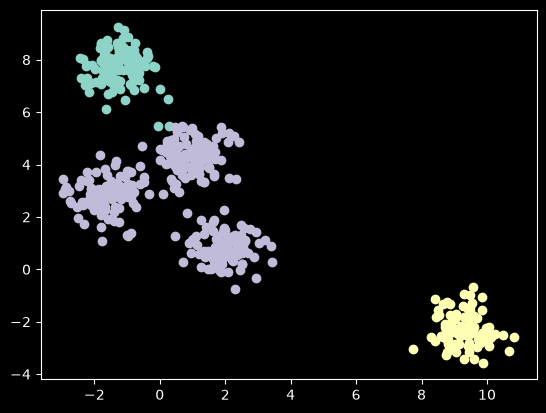

In [530]:
for cluster in kmeans_clusters:
 # get row indexes for samples with this cluster
 index = where(kmeans_result == cluster)
 # create scatter of these samples
 pyplot.scatter(training_data[index, 0], training_data[index, 1])
# show the kmeans plot
pyplot.show()

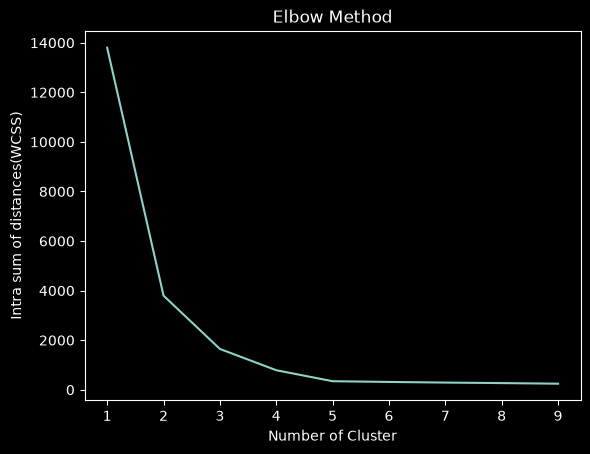

In [531]:
#Find the best number of clusters (elbow method)
#elbow method
max_cluster = 10
clusters = range(1,max_cluster)
intra_sum_of_square_list = []
for k in clusters:
    km = KMeans(n_clusters=k,init="k-means++", n_init=10, max_iter=300)
    km.fit(training_data)
    intra_sum_of_square_list.append(km.inertia_)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Cluster")
ax.set_ylabel("Intra sum of distances(WCSS)")
plt.plot(clusters,intra_sum_of_square_list)

In [532]:
kmeans_model = KMeans(n_clusters=4)
km = KMeans(n_clusters=4,init="k-means++", n_init=10, max_iter=300)
km.fit(training_data)
error = km.inertia_
kmeans_model.fit(training_data)
kmeans_result = kmeans_model.predict(training_data)
kmeans_clusters = unique(kmeans_result)
print ("Sum of Square Errors:", error)

Sum of Square Errors: 787.0676994559476


In [533]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from pathlib import Path

data_dir = Path("../data")
silver_dir = data_dir / "bronze"
df = pd.read_csv(silver_dir / "kddcup_testdata_unlabeled_10_percent.csv")

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print(df.head())

   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0              2       46     9        105        146     0   
1         0              2       46     9        105        146     0   
2         0              2       46     9        105        146     0   
3         0              2       46     9        105        146     0   
4         0              2       46     9        105        146     0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0               0       0    0  ...             255                 254   
1               0       0    0  ...             255                 254   
2               0       0    0  ...             255                 254   
3               0       0    0  ...             255                 254   
4               0       0    0  ...             255                 254   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                    0.01   
1   

In [534]:
from sklearn.metrics import silhouette_score
inertia = []
scores = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++',
        n_init=10
    )
    model.fit(df)
    inertia.append(model.inertia_)
    # labels = model.predict(df)
    # score = silhouette_score(df, labels)
    # scores.append(score)

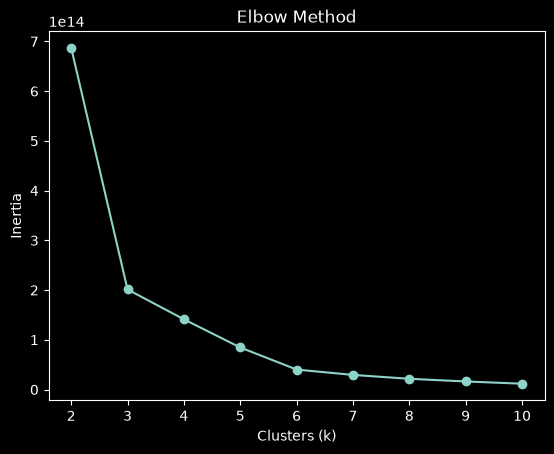

In [535]:
plt.plot(K, inertia, marker='o')
plt.xlabel("Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [536]:
# plt.plot(K, scores, marker='o')
# plt.xlabel("k")
# plt.ylabel("Silhouette score")
# plt.title("Silhouette analysis")
# plt.show()